# Plot figures relative to town masks

### Packages and Directories

In [35]:
# --- Imports ---
import os
import sys
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import dask
from dask.distributed import Client, LocalCluster
from scipy.interpolate import griddata
from statsmodels.stats.multitest import fdrcorrection
import calendar
from datetime import datetime, timedelta
import cftime

from scipy import ndimage

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- Custom Functions ---
# sys.path.append('/home/portal/script/python/precip_Cristina/')                    # tintin
sys.path.append('/home/alice/Desktop/work/git/myISACcode/python/precip_Cristina')   # alice
import functions_analogues_PrMax as fanPM
import functions_analogues_LUCAFAMOSS as fan

In [36]:
# Define directories for data and figures
# # tintin
# CERRA_dir = '/work_big/users/clima/portal/CERRA/'
# ERA5_dir = '/work_big/users/clima/portal/ERA5/'
# CRCM5_dir = '/work_big/users/clima/portal/CRCM5-LE/'
# fig_dir = '/home/portal/figures/analogues/'

# alice
CERRA_dir = '/media/alice/Crucial X9/portal/data_CNR/CERRA/'
ERA5_dir = '/media/alice/Crucial X9/portal/data_CNR/ERA5/'
CRCM5_dir = '/media/alice/Crucial X9/portal/data_CNR/CRCM5-LE/'
fig_dir = '/home/alice/Desktop/CNR/ENCIRCLE/materiale_alice/figures/'

### Parameters

In [123]:
# Variable
var = 'tas'

# Years
year_range = [1955, 2099]
no_years = year_range[1] - year_range[0] + 1

# Number of ensemble members
no_membs = 49

# List of members
list_membs = [name for name in os.listdir(CRCM5_dir + 'psl') if os.path.isdir(os.path.join(CRCM5_dir + 'psl', name))]
list_membs = sorted(list_membs)[:no_membs]  # Select the first 'no_membs' members

# time data
time_freq = 'seasonally' # 'seasonally' or 'yearly' or 'monthly'
if time_freq=='seasonally':
    season = 'SON' # 'DJF', 'MAM', 'JJA', 'SON'
    if season == 'DJF':
        iseas = 3
    elif season == 'MAM':
        iseas = 0
    elif season == 'JJA':
        iseas = 1
    elif season == 'SON':
        iseas = 2


### Upload data

In [124]:
# CRCM5-LE data
if time_freq=='yearly':
    array_membs = np.ones((no_membs,no_years))
if time_freq=='seasonally':
    array_membs = np.ones((no_membs,no_years*4-1))

for memb in list_membs:
    ds = xr.open_dataset(CRCM5_dir + var + '/' + memb + '/' +\
                    var + '_mean-Medregion_' + memb + '_' + time_freq + '_1955-2099.nc')
    array_membs[list_membs.index(memb),:] = ds['tas'].values.squeeze()
if time_freq=='seasonally':
    array_membs = array_membs[:,iseas::4]


In [125]:
t_past_model = np.mean(array_membs[:,:20], axis=(0,1))
t_present_model = np.mean(array_membs[:,49:49+20], axis=(0,1))
t_future_model = np.mean(array_membs[:,-20:], axis=(0,1))

In [126]:
# ERA5 data from nc file
era5_data = xr.open_dataset(ERA5_dir + 't2m/t2m_'+time_freq+'_1950-2025_europe_ERA5_regridded-to-CRCM5.nc')
# average in lon lat box with weights
era5_data_cut = era5_data.sel(lat=slice(30, 45), lon=slice(-10, 40))['t2m']
if time_freq=='seasonally':
    era5_data_cut = era5_data_cut.isel(time=slice(iseas, None, 4))
# cos weights
weights = np.cos(np.deg2rad(era5_data_cut['lat']))
weights = weights.broadcast_like(era5_data_cut.sel(time=era5_data_cut['time'].isel(time=0)))
# average in cut box
era5_data_med = era5_data_cut.weighted(weights).mean(dim=('lat', 'lon')).squeeze()
# years
era5_data_years = era5_data_med['time.year'].values

In [127]:
t_era5_past = era5_data_med.sel(time=slice('1955-01-01', '1974-12-31')).mean(dim='time')
t_era5_present = era5_data_med.sel(time=slice('2004-01-01', '2023-12-31')).mean(dim='time')

# Plot data

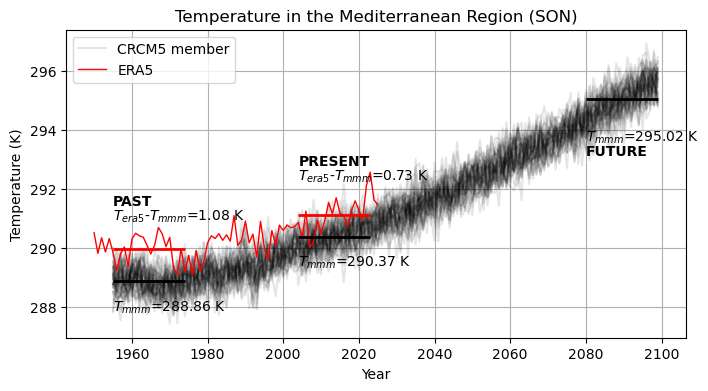

In [128]:
# Plot figure
plt.figure(figsize=(8, 4))

# Plot model ensemble members
for i in range(no_membs):
    if i == 0:
        plt.plot(np.arange(year_range[0], year_range[1]+1), array_membs[i, :], color='k', alpha=0.1, label='CRCM5 member')
    else:
        plt.plot(np.arange(year_range[0], year_range[1]+1), array_membs[i, :], color='k', alpha=0.1)

# Plot ERA5 data
plt.plot(era5_data_years, era5_data_med, color='r', label='ERA5', linewidth=1)

# plot lines for past mean
plt.hlines(y=t_past_model, xmin=1955, xmax=1974, color='k', linestyle='-', linewidth=2)
plt.hlines(y=t_era5_past, xmin=1955, xmax=1974, color='r', linestyle='-', linewidth=2)
plt.text(1955, t_era5_past + 1.5, f'PAST', color='k', fontweight='bold')
plt.text(1955, t_era5_past + 1, f'$T_{{era5}}$-$T_{{mmm}}$={t_era5_past-t_past_model:.2f} K', color='k')
plt.text(1955, t_past_model - 1, f'$T_{{mmm}}$={t_past_model:.2f} K', color='k')

# plot lines for present mean
plt.hlines(y=t_present_model, xmin=2004, xmax=2023, color='k', linestyle='-', linewidth=2)
plt.hlines(y=t_era5_present, xmin=2004, xmax=2023, color='r', linestyle='-', linewidth=2)
plt.text(2004, t_era5_present + 1.7, f'PRESENT', color='k', fontweight='bold')
plt.text(2004, t_era5_present + 1.2, f'$T_{{era5}}$-$T_{{mmm}}$={t_era5_present-t_present_model:.2f} K', color='k')
plt.text(2004, t_present_model - 1, f'$T_{{mmm}}$={t_present_model:.2f} K', color='k')

# plot lines for future mean
plt.hlines(y=t_future_model, xmin=2080, xmax=2099, color='k', linestyle='-', linewidth=2)
plt.text(2080, t_future_model - 1.4, f'$T_{{mmm}}$={t_future_model:.2f} K', color='k')
plt.text(2080, t_future_model - 1.9, f'FUTURE', color='k', fontweight='bold')

if time_freq == 'seasonally':
    str_title = f'Temperature in the Mediterranean Region ({season})'
    str_fig = f'tas_{season}_Mediterranean-region_ERA5-vs-CRCM5-LE.png'
elif time_freq == 'yearly':
    str_title = f'Temperature in the Mediterranean Region (Yearly)'
    str_fig = f'tas_yearly_Mediterranean-region_ERA5-vs-CRCM5-LE.png'

plt.title(str_title)
plt.xlabel('Year')
plt.ylabel('Temperature (K)')
plt.legend()
plt.grid()

plt.savefig(fig_dir + str_fig, dpi=300, bbox_inches='tight')
plt.show()